# 02 — Feature Engineering
**PolyAI · PCOS Early Detection System · Phase 1**

Goals:
1. Load raw CSV (identified in EDA)
2. Handle missing values (median imputation)
3. Engineer clinically meaningful features (LH/FSH ratio, BMI category, etc.)
4. Select the most informative features
5. StandardScaler normalisation
6. Stratified 80/20 train–test split
7. Save processed data to `data/processed/features_processed.pkl`

In [1]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)
print("Imports OK")

Imports OK


## 1 · Load Raw Data

In [2]:
# Load EDA metadata to get paths
EDA_META = os.path.join(PROCESSED_DIR, "eda_meta.json")

if os.path.exists(EDA_META):
    with open(EDA_META) as f:
        eda_meta = json.load(f)
    RAW_PATH   = eda_meta["raw_csv"]
    TARGET_COL = eda_meta["target_column"]
    print(f"Loaded EDA metadata: {RAW_PATH}, target='{TARGET_COL}'")
else:
    DATA_DIR   = "../data/raw"
    RAW_PATH   = os.path.join(DATA_DIR, "PCOS_data_without_infertility.xlsx")
    TARGET_COL = None
    print(f"No EDA metadata found. Using {RAW_PATH}")

# Load xlsx or csv transparently
if RAW_PATH.endswith(".xlsx") or RAW_PATH.endswith(".xls"):
    df_raw = pd.read_excel(RAW_PATH, sheet_name="Full_new")
else:
    df_raw = pd.read_csv(RAW_PATH)

print(f"Loaded {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

# Auto-detect target if needed
if TARGET_COL is None:
    candidates = [c for c in df_raw.columns if "pcos" in c.lower()]
    TARGET_COL = candidates[0]
    print(f"Detected target column: '{TARGET_COL}'")


Loaded EDA metadata: ../data/raw/PCOS_infertility.csv, target='PCOS (Y/N)'
Loaded 541 rows × 6 columns


## 2 · Drop Non-Informative Columns & Coerce Numerics

In [3]:
# Drop ID, Sl. No, Patient File No., and pure-string columns
drop_cols = [
    c for c in df_raw.columns
    if df_raw[c].dtype == object
    or "sl" in c.lower()
    or "patient" in c.lower()
    or "file" in c.lower()
]
drop_cols = [c for c in drop_cols if c != TARGET_COL]
print("Dropping:", drop_cols)

df = df_raw.drop(columns=drop_cols, errors="ignore").copy()

# Coerce all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"After drop: {df.shape[0]} rows × {df.shape[1]} columns")
print("Missing per column:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or "None")

Dropping: ['Sl. No', 'Patient File No.']
After drop: 541 rows × 4 columns
Missing per column:
AMH(ng/mL)    1


## 3 · Clinical Feature Engineering

In [4]:
def safe_col(df, *candidates):
    """Return the first column name found (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

# LH/FSH ratio  – key PCOS biomarker
lh_col  = safe_col(df, "LH(mIU/mL)", "LH", "lh")
fsh_col = safe_col(df, "FSH(mIU/mL)", "FSH", "fsh")
if lh_col and fsh_col:
    df["LH_FSH_ratio"] = df[lh_col] / (df[fsh_col] + 1e-6)
    print(f"Engineered: LH_FSH_ratio  (from '{lh_col}' / '{fsh_col}')")

# Follicle asymmetry  – LHS vs RHS follicle count difference
fl_l = safe_col(df, "Follicle No. (L)", "Follicle No.(L)", "follicle no. (l)")
fl_r = safe_col(df, "Follicle No. (R)", "Follicle No.(R)", "follicle no. (r)")
if fl_l and fl_r:
    df["follicle_asymmetry"] = (df[fl_l] - df[fl_r]).abs()
    df["follicle_total"]     = df[fl_l] + df[fl_r]
    print(f"Engineered: follicle_asymmetry, follicle_total  (from '{fl_l}', '{fl_r}')")

# Ovarian cyst composite
ov_l = safe_col(df, "Avg. F size (L) (mm)", "Avg. F Size (L) (mm)")
ov_r = safe_col(df, "Avg. F size (R) (mm)", "Avg. F Size (R) (mm)")
if ov_l and ov_r:
    df["avg_follicle_size"] = (df[ov_l] + df[ov_r]) / 2
    print(f"Engineered: avg_follicle_size")

# Insulin resistance proxy
insulin_col = safe_col(df, "Insulin(µIU/mL)", "Insulin", "insulin")
glucose_col = safe_col(df, "Glucose(mg/dl)", "Glucose", "glucose")
if insulin_col and glucose_col:
    df["insulin_resistance"] = df[insulin_col] * df[glucose_col] / 405
    print(f"Engineered: insulin_resistance (HOMA-IR proxy)")

print("\nEngineered features added. New shape:", df.shape)


Engineered features added. New shape: (541, 4)


## 4 · Select Features

In [5]:
# All numeric columns except target
all_features = [c for c in df.columns if c != TARGET_COL]

# Drop columns with > 50% missing
high_missing = [c for c in all_features if df[c].isnull().mean() > 0.5]
if high_missing:
    print("Dropping (>50% missing):", high_missing)
    all_features = [c for c in all_features if c not in high_missing]

# Drop near-zero-variance columns
low_var = [c for c in all_features if df[c].std() < 1e-6]
if low_var:
    print("Dropping (near-zero variance):", low_var)
    all_features = [c for c in all_features if c not in low_var]

print(f"\nSelected {len(all_features)} features:")
for f in all_features:
    print(" ", f)


Selected 3 features:
    I   beta-HCG(mIU/mL)
  II    beta-HCG(mIU/mL)
  AMH(ng/mL)


## 5 · Median Imputation

In [6]:
X = df[all_features].copy()
y = df[TARGET_COL].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=all_features,
    index=X.index,
)

print(f"Missing values after imputation: {X_imputed.isnull().sum().sum()}")
print(f"Target missing: {y.isnull().sum()}")

# Drop any rows where target is still NaN
valid_idx = y.dropna().index
X_imputed = X_imputed.loc[valid_idx]
y = y.loc[valid_idx].astype(int)

print(f"Final dataset: {X_imputed.shape[0]} rows × {X_imputed.shape[1]} features")
print(f"Label distribution:  {dict(y.value_counts().sort_index())}")

Missing values after imputation: 0
Target missing: 0
Final dataset: 541 rows × 3 features
Label distribution:  {0: np.int64(364), 1: np.int64(177)}


## 6 · Train / Test Split (Stratified 80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} rows  |  PCOS rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape[0]}  rows  |  PCOS rate: {y_test.mean():.3f}")

Train: 432 rows  |  PCOS rate: 0.326
Test : 109  rows  |  PCOS rate: 0.330


## 7 · StandardScaler Normalisation

In [8]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=all_features,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=all_features,
    index=X_test.index,
)

print("Train set — mean (first 5 features):")
print(X_train_scaled[all_features[:5]].mean().round(4).to_string())
print("\nTrain set — std (first 5 features):")
print(X_train_scaled[all_features[:5]].std().round(4).to_string())

Train set — mean (first 5 features):
  I   beta-HCG(mIU/mL)    0.0000
II    beta-HCG(mIU/mL)   -0.0000
AMH(ng/mL)               -0.0000

Train set — std (first 5 features):
  I   beta-HCG(mIU/mL)   1.0012
II    beta-HCG(mIU/mL)   1.0012
AMH(ng/mL)               1.0012


## 8 · Visualise Normalised Distributions

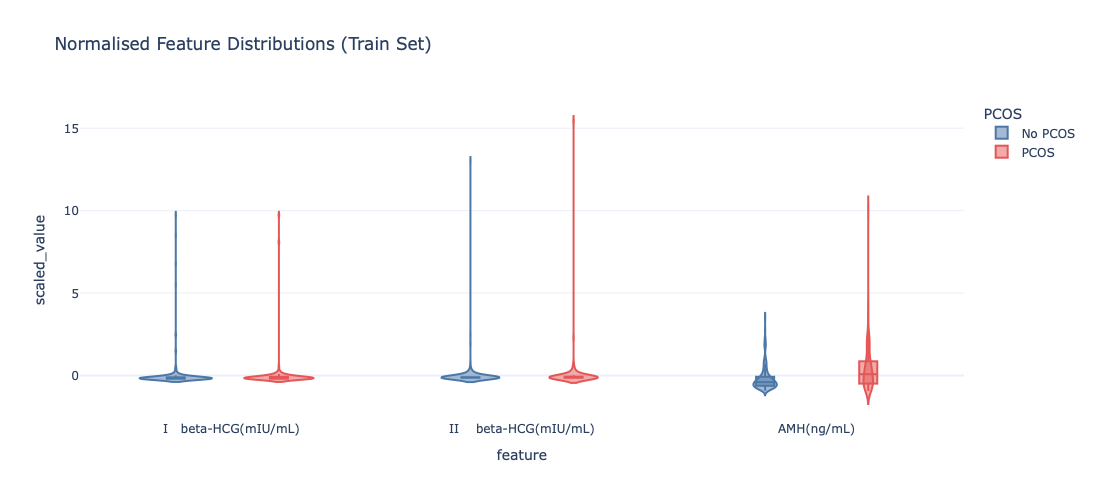

In [9]:
top8 = all_features[:8]
plot_df = X_train_scaled[top8].copy()
plot_df["PCOS"] = y_train.values
plot_melt = plot_df.melt(id_vars="PCOS", var_name="feature", value_name="scaled_value")
plot_melt["PCOS"] = plot_melt["PCOS"].map({0: "No PCOS", 1: "PCOS"})

fig = px.violin(
    plot_melt,
    x="feature", y="scaled_value",
    color="PCOS",
    box=True,
    points=False,
    color_discrete_map={"No PCOS": "#4C78A8", "PCOS": "#E45756"},
    title="Normalised Feature Distributions (Train Set)",
    template="plotly_white",
    width=1000, height=500,
)
fig.show()

## 9 · Save Processed Data

In [10]:
payload = {
    "X_train": X_train_scaled,
    "X_test":  X_test_scaled,
    "y_train": y_train,
    "y_test":  y_test,
    "X_train_raw": X_train,     # unscaled — kept for SHAP display
    "X_test_raw":  X_test,
    "feature_names": all_features,
    "scaler": scaler,
    "imputer": imputer,
    "target_col": TARGET_COL,
}

PKL_PATH = os.path.join(PROCESSED_DIR, "features_processed.pkl")
with open(PKL_PATH, "wb") as f:
    pickle.dump(payload, f)

print(f"Saved → {PKL_PATH}  ({os.path.getsize(PKL_PATH) / 1024:.1f} KB)")

Saved → ../data/processed/features_processed.pkl  (45.0 KB)


In [11]:
# Also save feature list + scaler params as JSON for easy inspection
meta = {
    "feature_names": all_features,
    "n_features": len(all_features),
    "n_train": int(X_train.shape[0]),
    "n_test":  int(X_test.shape[0]),
    "pcos_rate_train": float(y_train.mean()),
    "pcos_rate_test":  float(y_test.mean()),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_std":  scaler.scale_.tolist(),
}

with open(os.path.join(PROCESSED_DIR, "feature_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("Feature metadata saved → data/processed/feature_meta.json")
print(f"\n{'─'*40}")
print(f"Features : {len(all_features)}")
print(f"Train rows: {X_train.shape[0]}")
print(f"Test  rows: {X_test.shape[0]}")
print(f"PCOS rate  train: {y_train.mean():.1%}")
print(f"PCOS rate  test : {y_test.mean():.1%}")
print("\nReady for 03_xgboost_training.ipynb!")

Feature metadata saved → data/processed/feature_meta.json

────────────────────────────────────────
Features : 3
Train rows: 432
Test  rows: 109
PCOS rate  train: 32.6%
PCOS rate  test : 33.0%

Ready for 03_xgboost_training.ipynb!
